In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

CÉLULA 1 — Instalar bibliotecas

In [2]:
!pip install pyreaddbc dbfread -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 864.1 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.4/479.4 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pygit2 1.19.1 requires cffi>=2.0, but you have cffi 1.17.1 which is incompatible.


**CÉLULA 2 — Imports**

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from urllib.request import urlretrieve
from pyreaddbc import dbc2dbf
from dbfread import DBF

CÉLULA 3 — Configuração

In [4]:
ESTADOS = [
    "AC","AL","AP","AM","BA","CE","DF","ES","GO","MA",
    "MT","MS","MG","PA","PB","PR","PE","PI","RJ","RN",
    "RS","RO","RR","SC","SP","SE","TO"
]

ANOS = range(2018, 2023)

pasta_base = Path("/kaggle/working/dados_sus")
pasta_base.mkdir(exist_ok=True)

**CÉLULA 4** FUNÇÕES


In [5]:
def baixar_arquivo(url, destino):
    if destino.exists():
        return True
    try:
        urlretrieve(url, destino)
        return True
    except:
        return False


def ler_e_limpar_dbc(caminho_dbc):
    caminho_dbf = caminho_dbc.with_suffix(".dbf")

    try:
        dbc2dbf(str(caminho_dbc), str(caminho_dbf))
        df = pd.DataFrame(iter(DBF(str(caminho_dbf), encoding="latin1")))

        if caminho_dbf.exists():
            os.remove(caminho_dbf)

        return df
    except:
        return None

CÉLULA 5 — Baixar + processar IAM

In [6]:
resultados = []

for uf in ESTADOS:
    print(f"Processando {uf}...")

    for ano in ANOS:

        nome = f"DO{uf}{ano}.dbc"
        url = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"
        caminho = pasta_base / nome

        if baixar_arquivo(url, caminho):

            df = ler_e_limpar_dbc(caminho)

            if df is not None:

                df["CAUSABAS"] = df["CAUSABAS"].astype(str)

                # IAM = CID I21
                df = df[df["CAUSABAS"].str.startswith("I21")]

                df["SEXO_DESC"] = df["SEXO"].map({
                    1: "Masc",
                    2: "Fem",
                    "1": "Masc",
                    "2": "Fem"
                })

                resumo = (
                    df.groupby("SEXO_DESC")
                    .size()
                    .reset_index(name="OBITOS")
                )

                resumo["ANO"] = ano
                resultados.append(resumo)

Processando AC...
Processando AL...
Processando AP...
Processando AM...
Processando BA...
Processando CE...
Processando DF...
Processando ES...
Processando GO...
Processando MA...
Processando MT...
Processando MS...
Processando MG...
Processando PA...
Processando PB...
Processando PR...
Processando PE...
Processando PI...
Processando RJ...
Processando RN...
Processando RS...
Processando RO...
Processando RR...
Processando SC...
Processando SP...
Processando SE...
Processando TO...


**CÉLULA 6 — Gerar gráfico**

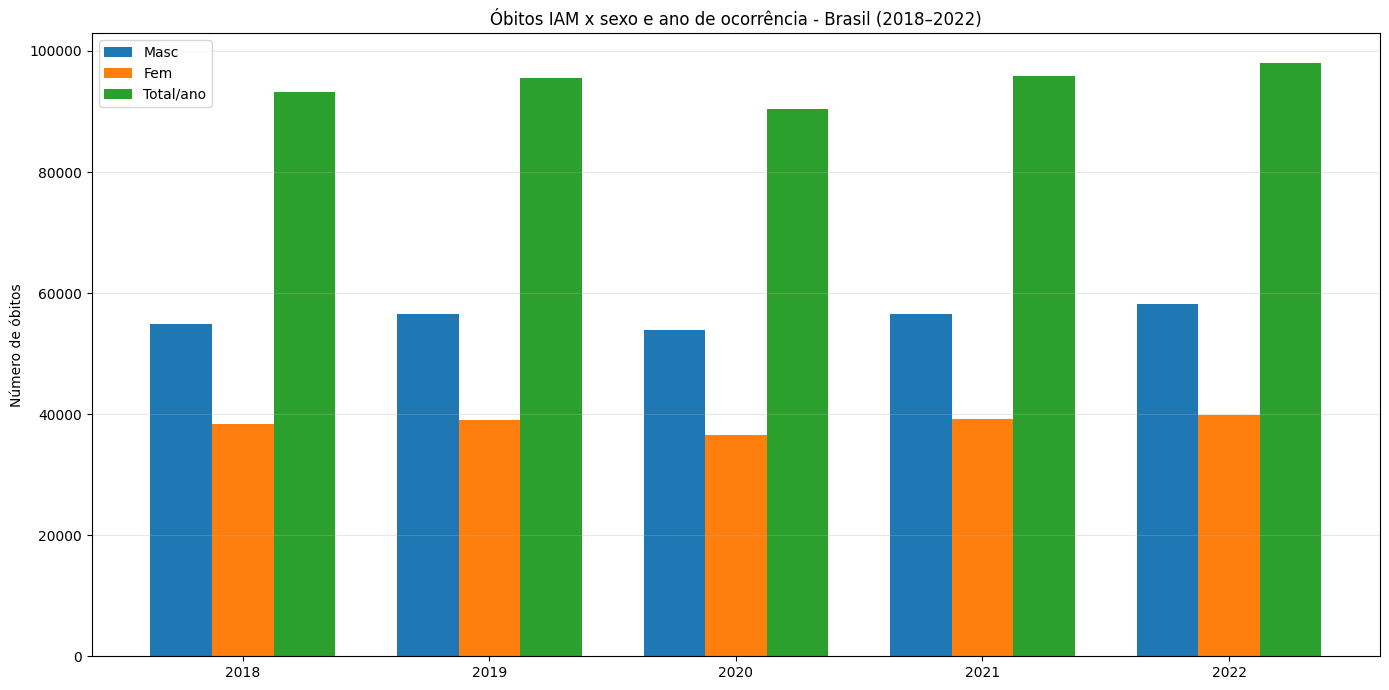

In [7]:
df_final = pd.concat(resultados)

grafico = (
    df_final
    .groupby(["ANO", "SEXO_DESC"])["OBITOS"]
    .sum()
    .unstack(fill_value=0)
)

grafico["Total"] = grafico["Masc"] + grafico["Fem"]

anos = grafico.index.astype(str)
x = np.arange(len(anos))
width = 0.25

fig, ax = plt.subplots(figsize=(14,7))

ax.bar(x - width, grafico["Masc"], width, label="Masc")
ax.bar(x, grafico["Fem"], width, label="Fem")
ax.bar(x + width, grafico["Total"], width, label="Total/ano")

ax.set_title("Óbitos IAM x sexo e ano de ocorrência - Brasil (2018–2022)")
ax.set_ylabel("Número de óbitos")
ax.set_xticks(x)
ax.set_xticklabels(anos)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

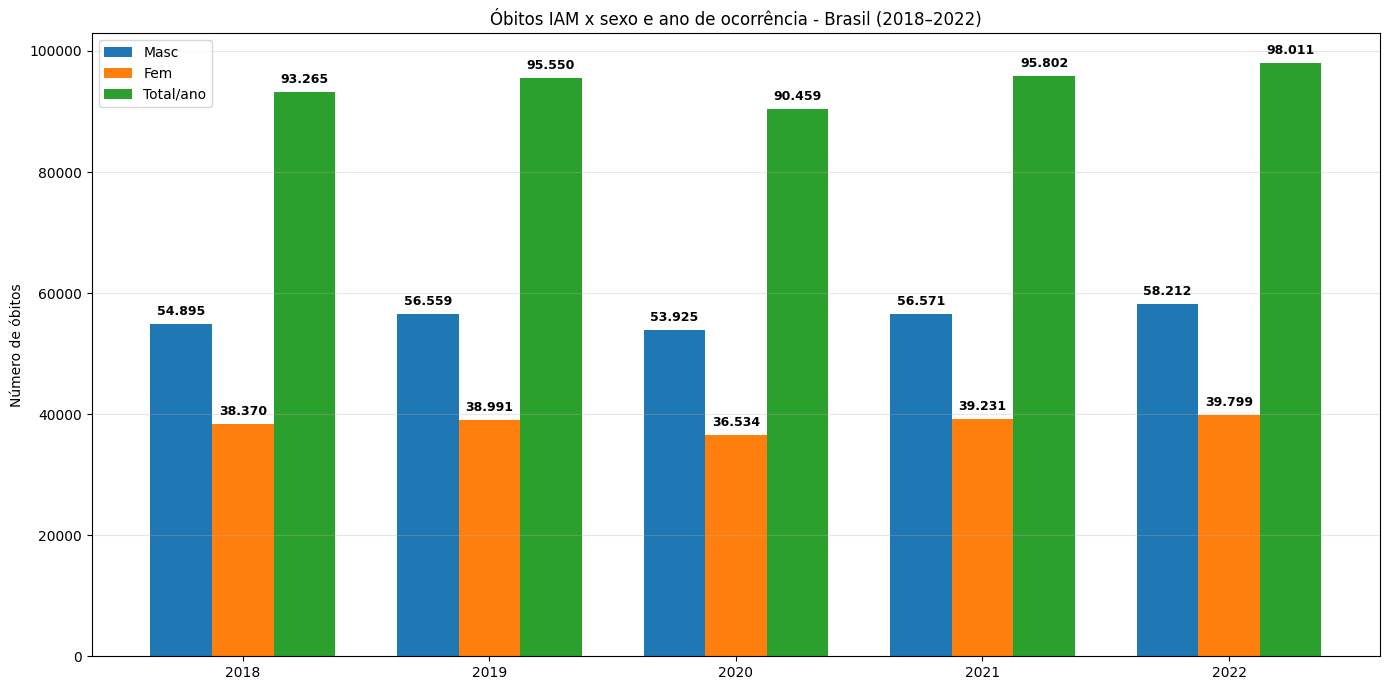

In [8]:
df_final = pd.concat(resultados)

grafico = (
    df_final
    .groupby(["ANO", "SEXO_DESC"])["OBITOS"]
    .sum()
    .unstack(fill_value=0)
)

grafico["Total/ano"] = grafico["Masc"] + grafico["Fem"]

anos = grafico.index.astype(str)
x = np.arange(len(anos))
width = 0.25

fig, ax = plt.subplots(figsize=(14,7))

b1 = ax.bar(x - width, grafico["Masc"], width, label="Masc")
b2 = ax.bar(x, grafico["Fem"], width, label="Fem")
b3 = ax.bar(x + width, grafico["Total/ano"], width, label="Total/ano")

ax.set_title("Óbitos IAM x sexo e ano de ocorrência - Brasil (2018–2022)")
ax.set_ylabel("Número de óbitos")
ax.set_xticks(x)
ax.set_xticklabels(anos)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# RÓTULOS NAS BARRAS
for barras in [b1, b2, b3]:
    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width()/2,
            altura + 1000,
            f"{int(altura):,}".replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [9]:
# Corrigir idade no SIM/DATASUS
df["IDADE_STR"] = df["IDADE"].astype(str).str.zfill(3)

def idade_sim(x):
    if x.startswith("4"):
        return int(x[1:3])      # idade em anos: 460 = 60 anos
    elif x.startswith("5"):
        return 100              # 500+ = 100 anos ou mais
    else:
        return None

df["IDADE_ANOS"] = df["IDADE_STR"].apply(idade_sim)

# IAM em idosos
df = df[
    (df["CAUSABAS"].astype(str).str.startswith("I21")) &
    (df["IDADE_ANOS"] >= 60)
]

2020-2025 idosos


In [10]:
# ================================
# CONFIGURAÇÃO
# ================================

ESTADOS = [
    "AC","AL","AP","AM","BA","CE","DF","ES","GO","MA",
    "MT","MS","MG","PA","PB","PR","PE","PI","RJ","RN",
    "RS","RO","RR","SC","SP","SE","TO"
]

ANOS = range(2021, 2026)   # 2021 até 2025

# ================================
# FILTRO IAM + IDOSOS
# ================================

resultados = []

for uf in ESTADOS:
    print(f"Processando {uf}...")

    for ano in ANOS:

        nome = f"DO{uf}{ano}.dbc"
        url = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"
        caminho = pasta_base / nome

        if baixar_arquivo(url, caminho):

            df = ler_e_limpar_dbc(caminho)

            if df is not None:

                # Converter idade SIM
                df["IDADE_STR"] = df["IDADE"].astype(str).str.zfill(3)

                def idade_sim(x):
                    if x.startswith("4"):
                        return int(x[1:3])
                    elif x.startswith("5"):
                        return 100
                    return None

                df["IDADE_ANOS"] = df["IDADE_STR"].apply(idade_sim)

                # Filtrar IAM em idosos
                df = df[
                    (df["CAUSABAS"].astype(str).str.startswith("I21")) &
                    (df["IDADE_ANOS"] >= 60)
                ]

                # Sexo
                df["SEXO_DESC"] = df["SEXO"].map({
                    1: "Masc",
                    2: "Fem",
                    "1": "Masc",
                    "2": "Fem"
                })

                resumo = (
                    df.groupby("SEXO_DESC")
                    .size()
                    .reset_index(name="OBITOS")
                )

                resumo["ANO"] = ano
                resultados.append(resumo)

Processando AC...
Processando AL...
Processando AP...
Processando AM...
Processando BA...
Processando CE...
Processando DF...
Processando ES...
Processando GO...
Processando MA...
Processando MT...
Processando MS...
Processando MG...
Processando PA...
Processando PB...
Processando PR...
Processando PE...
Processando PI...
Processando RJ...
Processando RN...
Processando RS...
Processando RO...
Processando RR...
Processando SC...
Processando SP...
Processando SE...
Processando TO...
